# 02 - SQL analysis of NMR oil data with MySQL

This notebook demonstrates how a processed NMR oil dataset can be transformed into a relational **MySQL** database and analyzed with SQL.

The workflow includes:

1. loading the processed CSV file,
2. preparing normalized relational tables,
3. connecting to a MySQL server and creating a database,
4. creating tables with primary and foreign keys,
5. inserting the sample and NMR measurement records,
6. loading queries from `oils_analysis.sql`,
7. presenting query results as tables and plots,
8. interpreting the main results.

The notebook expects the output of `01_data_preparation.ipynb`:

```text
data/processed/oils_processed.csv
```

It also expects a running MySQL Server. The database is stored by MySQL Server, not inside the notebook as a `.db` file.

## 1. Required Python packages

In [2]:
%pip install mysql-connector-python python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [3]:
import mysql.connector
from dotenv import load_dotenv

print("MySQL packages imported successfully.")

MySQL packages imported successfully.


## 2. Import libraries

In [4]:
from pathlib import Path
PROJECT_DIR = Path("..")

FIGURES_DIR = PROJECT_DIR / "diagrams" / "02"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(FIGURES_DIR)

../diagrams/02


In [5]:
from pathlib import Path
from getpass import getpass
import os
import re

import pandas as pd
import matplotlib.pyplot as plt

import mysql.connector
from dotenv import load_dotenv

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)

## 3. Define project paths

In [6]:
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "oils_processed.csv"
SQL_PATH = PROJECT_ROOT / "sql" / "oils_analysis.sql"
ENV_PATH = PROJECT_ROOT / "sql" /".env"

print(f"Data path: {DATA_PATH.resolve()}")
print(f"SQL path:  {SQL_PATH.resolve()}")
print(f"Data file exists: {DATA_PATH.exists()}")
print(f"SQL file exists:  {SQL_PATH.exists()}")

Data path: /home/gabi/Documents/Documents/NMR_analysis/data/processed/oils_processed.csv
SQL path:  /home/gabi/Documents/Documents/NMR_analysis/sql/oils_analysis.sql
Data file exists: True
SQL file exists:  True


## 4. Load the processed CSV file

In [7]:
data = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {data.shape}")
display(data.head())

Dataset shape: (149, 28)


,Primary ID,Date,Oil type,Manufacturer,Batch number,Spectra number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,1,2025-10-07,Amaranth oil,A,43739,1,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,2,2025-10-07,Amaranth oil,A,43739,2,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,3,2025-10-08,Amaranth oil,A,43739,3,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,4,2025-10-10,Amaranth oil,B,43466,4,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,5.95,95.18,658.60,14.73,0.13,0.10,0.25
4,5,2025-11-02,Amaranth oil,B,43466,5,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,291.22,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


The SQL analysis uses the processed dataset. Missing NMR values already have been handled in `01_data_preparation.ipynb`.

## 5. Prepare column names and data types

In [8]:
column_mapping = {"Primary ID": "sample_id", "Date": "measurement_date", "Oil type": "oil_type",
    "Manufacturer": "manufacturer", "Batch number": "batch_number", "Spectra number": "spectra_number"}

data_sql = data.rename(columns=column_mapping).copy()

required_metadata = list(column_mapping.values())
missing_metadata = [column for column in required_metadata if column not in data_sql.columns]

if missing_metadata:
    raise KeyError(f"Missing required columns: {missing_metadata}")

# Validate and convert the primary identifier.
sample_id_candidate = pd.to_numeric(data_sql["sample_id"], errors="coerce")

assert sample_id_candidate.notna().all(),"Some sample IDs are missing or non-numeric."
assert sample_id_candidate.is_unique,"Sample IDs must be unique before they can be used as a primary key."

data_sql["sample_id"] = sample_id_candidate.astype(int)

# Convert dates to Python date objects accepted by MySQL Connector/Python.
original_date_mask = data_sql["measurement_date"].notna()
parsed_dates = pd.to_datetime(data_sql["measurement_date"], format="mixed", dayfirst=True, errors="coerce")

assert parsed_dates[original_date_mask].notna().all(),"Some measurement dates could not be converted."

data_sql["measurement_date"] = parsed_dates.dt.date

# Batch number is an identifier, so preserve it as text.
data_sql["batch_number"] = (data_sql["batch_number"] .astype("string") .str.strip() .replace({"": pd.NA}))

# Spectra number is numeric but may contain missing values.
data_sql["spectra_number"] = pd.to_numeric(data_sql["spectra_number"], errors="coerce").astype("Int64")

display(data_sql.head())

,sample_id,measurement_date,oil_type,manufacturer,batch_number,spectra_number,0.88 ppm,0.89 ppm,0.90 ppm,0.98 ppm,1.31 ppm,1.36 ppm,1.61 ppm,1.68 ppm,2.05 ppm,2.01 ppm,2.19 ppm,2.31 ppm,2.77 ppm,4.14 ppm,4.29 ppm,5.12 ppm,5.26 ppm,5.34 ppm,5.43 ppm,5.69 ppm,6.05 ppm,6.45 ppm
0,1,2025-10-07,Amaranth oil,A,43739,1,125.47,15.67,12.34,11.18,5306.83,565.27,837.44,73.93,537.41,526.74,12.03,605.74,289.95,212.43,207.07,6.50,98.21,690.85,15.09,0.17,0.14,0.34
1,2,2025-10-07,Amaranth oil,A,43739,2,118.10,12.61,13.60,10.30,4961.43,543.99,798.57,73.89,493.14,559.02,10.17,576.95,278.62,202.45,200.15,6.18,93.73,657.26,14.80,0.16,0.13,0.34
2,3,2025-10-08,Amaranth oil,A,43739,3,120.78,14.86,12.87,10.92,5138.00,565.93,828.82,72.39,523.22,511.93,10.83,593.72,288.63,204.00,204.26,6.55,95.49,674.88,16.99,0.23,0.13,0.32
3,4,2025-10-10,Amaranth oil,B,43466,4,123.53,13.89,13.74,10.57,5255.57,534.17,828.79,85.30,532.51,511.78,10.76,586.82,281.73,207.87,197.60,5.95,95.18,658.60,14.73,0.13,0.10,0.25
4,5,2025-11-02,Amaranth oil,B,43466,5,131.93,14.88,15.07,11.60,5660.95,594.31,886.85,88.52,570.69,605.27,11.31,621.07,291.22,221.07,210.26,6.17,98.52,702.16,19.60,0.14,0.21,0.22


## 6. Identify the NMR variables

In [9]:
nmr_columns = [column for column in data_sql.columns if "ppm" in column.lower()]

print(f"Number of NMR variables: {len(nmr_columns)}")
print(nmr_columns)

Number of NMR variables: 22
['0.88 ppm', '0.89 ppm', '0.90 ppm', '0.98 ppm', '1.31 ppm', '1.36 ppm', '1.61 ppm', '1.68 ppm', '2.05 ppm', '2.01 ppm', '2.19 ppm', '2.31 ppm', '2.77 ppm', '4.14 ppm', '4.29 ppm', '5.12 ppm', '5.26 ppm', '5.34 ppm', '5.43 ppm', '5.69 ppm', '6.05 ppm', '6.45 ppm']


## 7. Create normalized relational DataFrames

The processed wide table is divided into:

- `samples`, containing one row per sample and its metadata;
- `nmr_measurements`, containing one NMR intensity per row.

This long relational structure supports joins, aggregations and window functions without creating a separate SQL column for every chemical shift.

In [10]:
samples = data_sql[["sample_id", 
                    "measurement_date", 
                    "oil_type", 
                    "manufacturer", 
                    "batch_number", 
                    "spectra_number"]].copy()

display(samples.head())

,sample_id,measurement_date,oil_type,manufacturer,batch_number,spectra_number
0,1,2025-10-07,Amaranth oil,A,43739,1
1,2,2025-10-07,Amaranth oil,A,43739,2
2,3,2025-10-08,Amaranth oil,A,43739,3
3,4,2025-10-10,Amaranth oil,B,43466,4
4,5,2025-11-02,Amaranth oil,B,43466,5


In [11]:
nmr_measurements = data_sql.melt(id_vars=["sample_id"], 
                                 value_vars=nmr_columns,
                                 var_name="chemical_shift_ppm", 
                                 value_name="intensity")

nmr_measurements["chemical_shift_ppm"] = (nmr_measurements["chemical_shift_ppm"] 
                                          .str.replace("ppm", "", regex=False) 
                                          .str.strip() 
                                          .astype(float))

nmr_measurements["intensity"] = pd.to_numeric(nmr_measurements["intensity"], )

nmr_measurements.insert(0, "measurement_id", range(1, len(nmr_measurements) + 1))

display(nmr_measurements.head())

,measurement_id,sample_id,chemical_shift_ppm,intensity
0,1,1,0.88,125.47
1,2,2,0.88,118.10
2,3,3,0.88,120.78
3,4,4,0.88,123.53
4,5,5,0.88,131.93


In [12]:
print("samples:", samples.shape)
print("nmr_measurements:", nmr_measurements.shape)

expected_measurements = len(samples) * len(nmr_columns)
print("Expected NMR rows:", expected_measurements)
print("Actual NMR rows:  ", len(nmr_measurements))

assert len(nmr_measurements) == expected_measurements
assert samples["sample_id"].is_unique
assert samples["oil_type"].notna().all()

print("Relational DataFrames validated.")

samples: (149, 6)
nmr_measurements: (3278, 4)
Expected NMR rows: 3278
Actual NMR rows:   3278
Relational DataFrames validated.


## 8. Configure the MySQL connection

project-root `.env` file:

```text
MYSQL_HOST=127.0.0.1
MYSQL_PORT=3306
MYSQL_USER=oils_user
MYSQL_PASSWORD=your_password
MYSQL_DATABASE=oils_nmr
```

In [13]:
if load_dotenv is not None and ENV_PATH.exists():
    load_dotenv(ENV_PATH)

MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

if MYSQL_PASSWORD is None:
    MYSQL_PASSWORD = getpass("MySQL password: ")

print(f"MySQL host: {MYSQL_HOST}:{MYSQL_PORT}")
print(f"MySQL user: {MYSQL_USER}")
print(f"Database:   {MYSQL_DATABASE}")

MySQL host: 127.0.0.1:3306
MySQL user: oils_user
Database:   oils_nmr


## 9. Connect to MySQL and create the database when needed

In [14]:
from mysql.connector import Error, errorcode

try:
    connection = mysql.connector.connect(
        host=MYSQL_HOST,
        port=MYSQL_PORT,
        user=MYSQL_USER,
        password=MYSQL_PASSWORD,
        database=MYSQL_DATABASE
    )

    print(f"Connected to MySQL database: {MYSQL_DATABASE}")
    print(f"MySQL user: {MYSQL_USER}")
    print(f"MySQL host: {MYSQL_HOST}:{MYSQL_PORT}")

except Error as exc:
    if exc.errno == errorcode.ER_BAD_DB_ERROR:
        raise ConnectionError(
            f"The database '{MYSQL_DATABASE}' does not exist. "
            "Create it first using a MySQL administrator account."
        ) from exc

    elif exc.errno == errorcode.ER_ACCESS_DENIED_ERROR:
        raise ConnectionError(
            "Access denied. Check the MySQL username, password "
            "and the user's permissions for this database."
        ) from exc

    else:
        raise ConnectionError(
            "Could not connect to MySQL. Check whether MySQL Server is running, "
            "the host and port are correct, and the database is available."
        ) from exc

Connected to MySQL database: oils_nmr
MySQL user: oils_user
MySQL host: 127.0.0.1:3306


## 10. Create the MySQL tables

The child table is dropped before the parent table because `nmr_measurements` references `samples`. MySQL uses the InnoDB engine so that the foreign key is enforced.

In [15]:
drop_statements = [
    "DROP TABLE IF EXISTS nmr_measurements",
    "DROP TABLE IF EXISTS samples"
]

create_statements = [
    """
    CREATE TABLE samples (
        sample_id INT PRIMARY KEY,
        measurement_date DATE,
        oil_type VARCHAR(100) NOT NULL,
        manufacturer VARCHAR(255),
        batch_number VARCHAR(100),
        spectra_number INT
    ) ENGINE=InnoDB
      DEFAULT CHARACTER SET utf8mb4
      COLLATE utf8mb4_unicode_ci
    """,
    """
    CREATE TABLE nmr_measurements (
        measurement_id BIGINT PRIMARY KEY,
        sample_id INT NOT NULL,
        chemical_shift_ppm DOUBLE NOT NULL,
        intensity DOUBLE,
        CONSTRAINT fk_nmr_measurements_sample
            FOREIGN KEY (sample_id)
            REFERENCES samples(sample_id)
            ON UPDATE CASCADE
            ON DELETE CASCADE,
        INDEX idx_nmr_sample_id (sample_id),
        INDEX idx_nmr_chemical_shift (chemical_shift_ppm)
    ) ENGINE=InnoDB
      DEFAULT CHARACTER SET utf8mb4
      COLLATE utf8mb4_unicode_ci
    """
]

cursor = connection.cursor()
try:
    for statement in drop_statements:
        cursor.execute(statement)

    for statement in create_statements:
        cursor.execute(statement)

    connection.commit()
finally:
    cursor.close()

print("MySQL tables created successfully.")

MySQL tables created successfully.


## 11. Prepare and insert records

In [16]:
sample_records = [(int(row.sample_id), None if pd.isna(row.measurement_date) else row.measurement_date, str(row.oil_type), None if pd.isna(row.manufacturer) else str(row.manufacturer),
    None if pd.isna(row.batch_number) else str(row.batch_number), None if pd.isna(row.spectra_number) else int(row.spectra_number)) for row in samples.itertuples(index=False)]

measurement_records = [(int(row.measurement_id), int(row.sample_id), float(row.chemical_shift_ppm),
    None if pd.isna(row.intensity) else float(row.intensity)) for row in nmr_measurements.itertuples(index=False)]

print(f"Prepared sample records: {len(sample_records)}")
print(f"Prepared NMR records:    {len(measurement_records)}")

Prepared sample records: 149
Prepared NMR records:    3278


In [17]:
insert_samples_sql = """
INSERT INTO samples (sample_id, measurement_date, oil_type, manufacturer, batch_number, spectra_number)
VALUES (%s, %s, %s, %s, %s, %s)
"""

insert_measurements_sql = """
INSERT INTO nmr_measurements (measurement_id, sample_id, chemical_shift_ppm, intensity)
VALUES (%s, %s, %s, %s)
"""

cursor = connection.cursor()
try:
    cursor.executemany(insert_samples_sql, sample_records)
    cursor.executemany(insert_measurements_sql, measurement_records)
    connection.commit()
except Exception:
    connection.rollback()
    raise
finally:
    cursor.close()

print(f"Inserted {len(sample_records)} rows into samples.")
print(f"Inserted {len(measurement_records)} rows into nmr_measurements.")

Inserted 149 rows into samples.
Inserted 3278 rows into nmr_measurements.


## 12. Helper function for returning MySQL results as pandas tables

In [18]:
def read_mysql_query(query, connection, params=None):
    """Execute one result-returning MySQL statement and return a DataFrame."""
    cursor = connection.cursor(dictionary=True)
    try:
        cursor.execute(query, params or ())
        rows = cursor.fetchall()
        columns = cursor.column_names
    finally:
        cursor.close()

    return pd.DataFrame(rows, columns=columns)

## 13. Inspect tables, columns and foreign keys

In [19]:
print("Tables")
display(read_mysql_query("SHOW TABLES", connection))

print("samples schema")
display(read_mysql_query("DESCRIBE samples", connection))

print("nmr_measurements schema")
display(read_mysql_query("DESCRIBE nmr_measurements", connection))

Tables


,Tables_in_oils_nmr
0,nmr_measurements
1,samples


samples schema


,Field,Type,Null,Key,Default,Extra
0,sample_id,int,NO,PRI,None,
1,measurement_date,date,YES,,None,
2,oil_type,varchar(100),NO,,None,
3,manufacturer,varchar(255),YES,,None,
4,batch_number,varchar(100),YES,,None,
5,spectra_number,int,YES,,None,


nmr_measurements schema


,Field,Type,Null,Key,Default,Extra
0,measurement_id,bigint,NO,PRI,None,
1,sample_id,int,NO,MUL,None,
2,chemical_shift_ppm,double,NO,MUL,None,
3,intensity,double,YES,,None,


In [20]:
foreign_keys = read_mysql_query(""" SELECT constraint_name, 
    table_name, column_name, referenced_table_name,
    referenced_column_name FROM information_schema.key_column_usage WHERE table_schema 
    = %s AND table_name = 'nmr_measurements' 
    AND referenced_table_name IS NOT NULL ORDER BY constraint_name, ordinal_position """, 
    connection, params=(MYSQL_DATABASE, ))

display(foreign_keys)

,CONSTRAINT_NAME,TABLE_NAME,COLUMN_NAME,REFERENCED_TABLE_NAME,REFERENCED_COLUMN_NAME
0,fk_nmr_measurements_sample,nmr_measurements,sample_id,samples,sample_id


In [21]:
row_counts = read_mysql_query(""" SELECT 'samples' AS table_name,
    COUNT(*) AS row_count FROM samples UNION ALL SELECT 'nmr_measurements' AS table_name, 
    COUNT(*) AS row_count FROM nmr_measurements """, connection)

display(row_counts)

assert int(row_counts.loc[row_counts["table_name"] == "samples", 
                          "row_count"].iloc[0]) == len(samples)

assert int(row_counts.loc[row_counts["table_name"] == "nmr_measurements",
                          "row_count"].iloc[0]) == len(nmr_measurements)

print("Database row counts validated.")

,table_name,row_count
0,samples,149
1,nmr_measurements,3278


Database row counts validated.


## 14. Load named queries from `oils_analysis.sql`

Each query in the SQL file begins with a comment in the form:

```sql
-- name: query_name
```

The loader below keeps the analytical SQL outside the notebook while making the results easy to present with pandas and Matplotlib.

In [22]:
def load_named_queries(sql_file):
    queries = {}
    current_name = None
    current_lines = []

    with open(sql_file, "r", encoding="utf-8") as file:
        for line in file:
            if line.strip().startswith("-- name:"):
                if current_name is not None:
                    queries[current_name] = "".join(current_lines).strip()

                current_name = line.split(":", 1)[1].strip()
                current_lines = []
            else:
                current_lines.append(line)

    if current_name is not None:
        queries[current_name] = "".join(current_lines).strip()

    return queries


if not SQL_PATH.exists():
    raise FileNotFoundError("SQL file not found. Place oils_analysis.sql in the sql directory.")

queries = load_named_queries(SQL_PATH)

print("Loaded queries:")
for query_name in queries:
    print(f"- {query_name}")

Loaded queries:
- samples_by_oil_type
- intensity_by_oil_type
- strongest_nmr_signals
- ranked_signals_by_oil_type
- measurements_by_manufacturer


## 15. Query 1: Number of samples by oil type

In [23]:
samples_by_type = read_mysql_query(queries["samples_by_oil_type"], connection)

display(samples_by_type)

,oil_type,number_of_samples
0,Amaranth oil,50
1,Sea buckthorn oil,50
2,Pomegranate oil,49


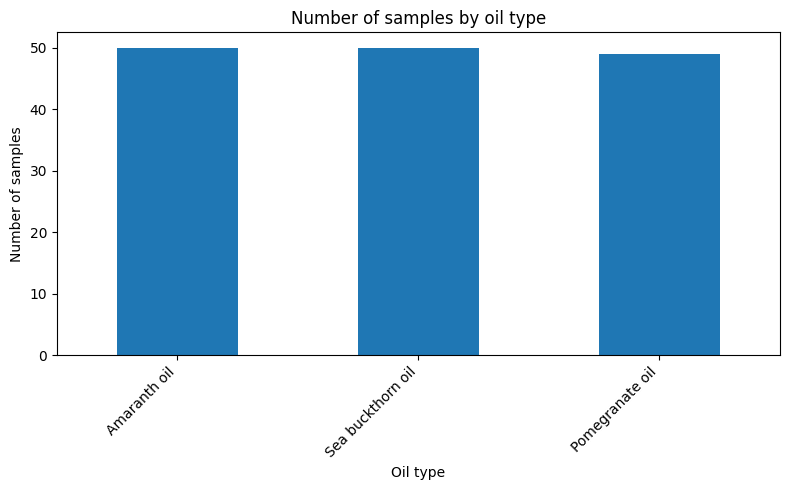

In [24]:
ax = samples_by_type.plot(x="oil_type", y="number_of_samples", kind="bar", 
                          legend=False, figsize=(8, 5))

ax.set_xlabel("Oil type")
ax.set_ylabel("Number of samples")
ax.set_title("Number of samples by oil type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Note:** This query shows the class distribution in the processed dataset. The same number of sample counts across oil types support balanced comparisons.

## 16. Query 2: Mean, minimum and maximum intensity by oil type and signal

In [25]:
intensity_summary = read_mysql_query(queries["intensity_by_oil_type"], connection)

display(intensity_summary.head(15))

,oil_type,chemical_shift_ppm,mean_intensity,min_intensity,max_intensity,available_measurements
0,Sea buckthorn oil,0.88,151.11,136.30,189.04,50
1,Amaranth oil,0.88,125.93,117.81,132.22,50
2,Pomegranate oil,0.88,38.26,30.82,43.95,49
3,Sea buckthorn oil,0.89,66.62,53.01,78.59,50
4,Amaranth oil,0.89,14.55,12.56,15.68,50
5,Pomegranate oil,0.89,9.33,8.38,10.15,49
6,Pomegranate oil,0.90,156.88,146.99,176.14,49
7,Sea buckthorn oil,0.90,21.63,13.97,26.47,50
8,Amaranth oil,0.90,13.55,12.33,15.14,50
9,Amaranth oil,0.98,11.05,10.26,11.65,50


**Note:**
- The strongest mean signal was observed at 1.31 ppm for all oil types.
- Sea buckthorn oil showed the highest mean intensities at 0.88, 0.89 and 1.31 ppm.
- Pomegranate oil was distinguished by a high mean intensity at 0.90 ppm.
- Non-overlapping minimum-maximum ranges at several chemical shifts suggest good discriminatory potential.
- At 0.98 ppm, amaranth and sea buckthorn oils showed similar values and overlapping ranges, indicating lower discriminatory ability.
- Sample sizes were balanced across oil types, supporting a fair comparison of group means.
- Statistical tests are still required to confirm whether the observed differences are significant.

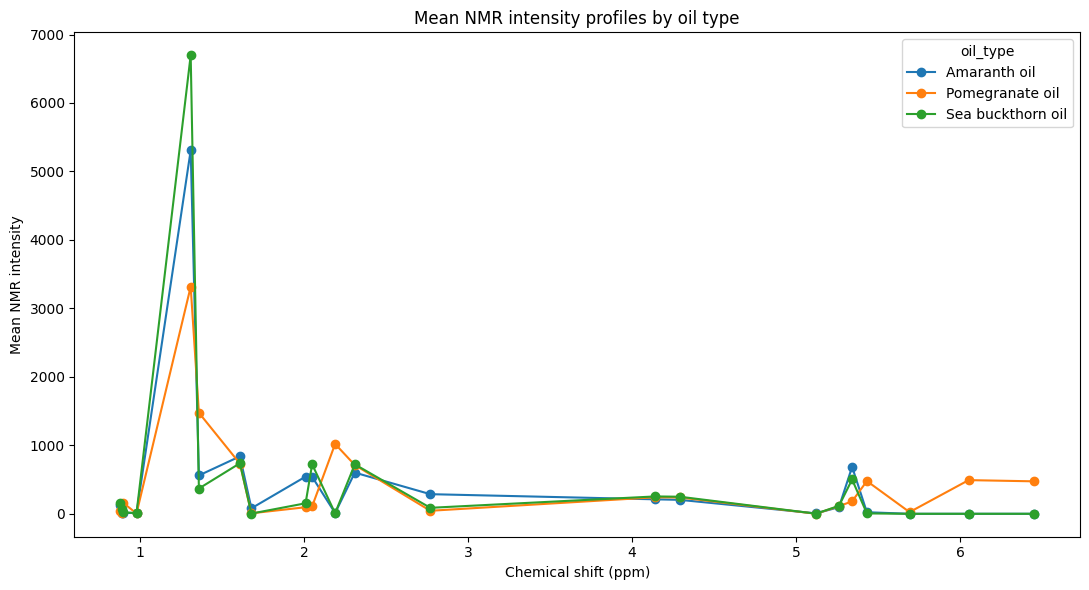

In [26]:
mean_profiles = intensity_summary.pivot(index="chemical_shift_ppm", columns="oil_type",
                                        values="mean_intensity").sort_index()

ax = mean_profiles.plot(figsize=(11, 6), marker="o")

ax.set_xlabel("Chemical shift (ppm)")
ax.set_ylabel("Mean NMR intensity")
ax.set_title("Mean NMR intensity profiles by oil type")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "sql_mean_intensity_by_oil.png",dpi=300,bbox_inches="tight")

plt.show()

**Interpretation:** 
- The mean profiles show how NMR intensity changes across chemical shifts for each oil type. 
- The dominant signal occurs in 1.31 ppm.
- Sea buckthorn oil has the highest mean intensity at this signal.
- Pomegranate oil shows a distinct profile in 2.19 ppm and in the region above 5.5 ppm.
- Signals with visibly different means may contribute to separation in later multivariate analyses.
- Chemical shifts with large differences between oils may support classification.
- Mean values alone do not show within-group variability or statistical significance.

## 17. Query 3: 10 strongest NMR signals

In [27]:
strongest_signals = read_mysql_query(queries["strongest_nmr_signals"], connection)

display(strongest_signals)

,oil_type,chemical_shift_ppm,mean_intensity
0,Sea buckthorn oil,1.31,6697.18
1,Amaranth oil,1.31,5308.65
2,Pomegranate oil,1.31,3316.70
3,Pomegranate oil,1.36,1475.69
4,Pomegranate oil,2.19,1020.38
5,Amaranth oil,1.61,838.77
6,Sea buckthorn oil,1.61,738.46
7,Pomegranate oil,1.61,732.47
8,Sea buckthorn oil,2.05,722.21
9,Sea buckthorn oil,2.31,721.67


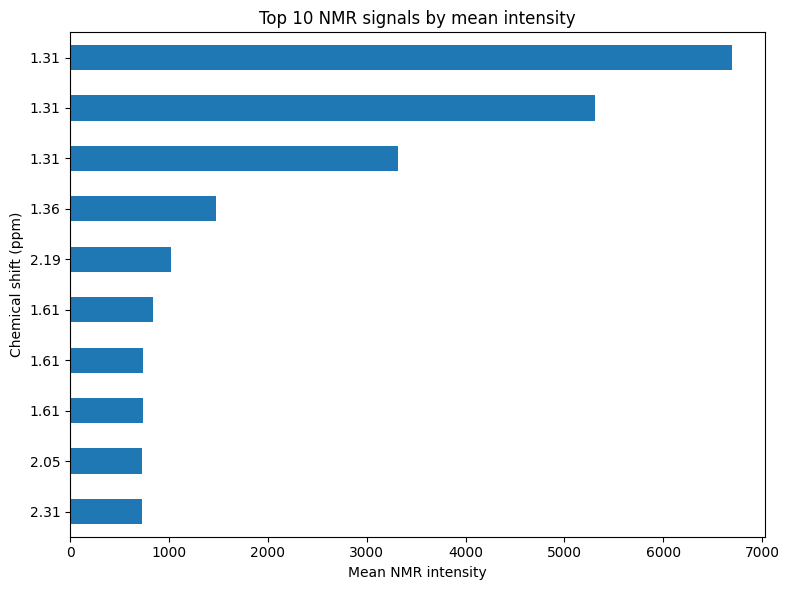

In [28]:
plot_data = strongest_signals.sort_values("mean_intensity")

ax = plot_data.plot(x="chemical_shift_ppm", y="mean_intensity", kind="barh", legend=False, figsize=(8, 6))

ax.set_xlabel("Mean NMR intensity")
ax.set_ylabel("Chemical shift (ppm)")
ax.set_title("Top 10 NMR signals by mean intensity")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sql_signal_ranking.png",dpi=300,bbox_inches="tight") 
plt.show()

**Interpretation:** 
- The strongest mean NMR signal was observed at 1.31 ppm for all three oil types.
- Sea buckthorn oil showed the highest mean intensity at this chemical shift, followed by amaranth and pomegranate oil.
- Pomegranate oil also displayed strong signals at 1.36 and 2.19 ppm, while amaranth oil showed an additional prominent signal at 1.61 ppm.
- Sea buckthorn oil was also represented among the strongest signals at 1.61, 2.05 and 2.31 ppm. These differences suggest that selected chemical shifts may contribute to distinguishing the oil types.
- However, the ranking is based only on mean intensity and does not account for within-group variability or statistical significance.
- This ranking identifies the chemical shifts with the highest mean intensity across the dataset. 
- High intensity alone does not guarantee that a signal distinguishes oil types, but it highlights dominant spectral regions.

## 19. Query 4: Ranking signals within each oil type

This query demonstrates:

- a common table expression with `WITH`,
- aggregation with `AVG`,
- a MySQL 8.0+ window function with `RANK() OVER`,
- partitioning by oil type.

In [29]:
ranked_signals = read_mysql_query(queries["ranked_signals_by_oil_type"], connection)
#display(ranked_signals.head(20))

In [30]:
top_ranked_by_oil = ranked_signals.query("signal_rank <= 5").copy()

display(top_ranked_by_oil)

,oil_type,chemical_shift_ppm,mean_intensity,signal_rank
0,Amaranth oil,1.31,5308.65,1
1,Amaranth oil,1.61,838.77,2
2,Amaranth oil,5.34,685.54,3
3,Amaranth oil,2.31,601.60,4
4,Amaranth oil,1.36,560.25,5
22,Pomegranate oil,1.31,3316.70,1
23,Pomegranate oil,1.36,1475.69,2
24,Pomegranate oil,2.19,1020.38,3
25,Pomegranate oil,1.61,732.47,4
26,Pomegranate oil,2.31,712.05,5


**Interpretation:** 
- The strongest mean NMR signal for all three oil types was observed at 1.31 ppm. 
- However, the ranking of the remaining signals differed between the oils. 
- Pomegranate oil showed particularly strong signals at 1.36 and 2.19 ppm, while amaranth oil was distinguished by a relatively strong signal at 5.34 ppm. 
- Sea buckthorn oil had the highest mean intensity at 1.31 ppm and its profile was strongly dominated by this signal. 
- These differences in signal ranking may help identify chemical shifts useful for distinguishing the oil types.
- The ranking is calculated separately for each oil type. 
- It reveals which chemical shifts have the strongest mean signals within each group rather than across the complete dataset.

## 20. Query 5: Number of samples by manufacturer

In [31]:
manufacturer_summary = read_mysql_query(queries["measurements_by_manufacturer"], connection)

display(manufacturer_summary)

,manufacturer,number_of_samples
0,A,46
1,C,40
2,B,32
3,D,31


**Interpretation**: Manufacturer A was represented by the largest number of samples, followed by manufacturer C. Manufacturers B and D had similar sample counts. Overall, the dataset was relatively balanced across manufacturers, although manufacturer A was slightly more strongly represented. No missing manufacturer category was present in the summary.

## 21. Close the MySQL connection

In [32]:
if connection.is_connected():
    connection.close()

print("MySQL connection closed.")

MySQL connection closed.


## Conclusions

This notebook demonstrated how to:

- connect Python and JupyterLab to a running MySQL Server;
- create a MySQL database and normalized InnoDB tables;
- reshape NMR measurements from wide to long format;
- define primary keys, a foreign key and indexes;
- insert multiple records with parameterized `executemany()` statements;
- inspect MySQL schemas using `SHOW`, `DESCRIBE` and `information_schema`;
- load analytical statements from an external `.sql` file;
- execute joins, aggregations, CTEs and window functions;
- present query results as pandas tables and Matplotlib plots;
- interpret the main analytical outputs.

Unlike SQLite, MySQL is a server-based database. The server must be installed and running independently of JupyterLab. The notebook connects to that server, creates/recreates the project database objects and loads the processed CSV data.